# Event Insight Visualization
This notebook connects to the `gsmate-server` SQLite database to visualize IoT event records and their corresponding sensor readings (accelerometer and gyroscope) for pre-event and post-event data.

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Set up plot style
plt.style.use('seaborn-v0_8-darkgrid')

# Connect to the SQLite database
db_path = "../db/sqlite.db"
conn = sqlite3.connect(db_path)

# Load the events
events_df = pd.read_sql_query("SELECT * FROM events", conn)
print(f"Total events found: {len(events_df)}")
display(events_df.head())

Total events found: 3


,id,device_id,time
0,1,100,1773530948
1,2,100,1773530997
2,3,100,1773531044


    id  event_id pre_post     acc_x     acc_y     acc_z       gyr_x  \
73  74         1      pre  0.031006  0.025879 -0.154053   30.625000   
74  75         1      pre  0.017578 -0.101562 -1.286133 -116.015624   

        gyr_y     gyr_z  sample_idx  
73  18.062500  6.640625          73  
74  36.109376 -0.421875          74  
    id  event_id pre_post     acc_x     acc_y     acc_z     gyr_x      gyr_y  \
75  76         1     post -0.215576 -0.495117 -0.364746 -232.8125  42.140624   
76  77         1     post -0.392822 -0.726562  0.721924 -190.3125  41.312500   

       gyr_z  sample_idx  
75 -6.328125          75  
76 -3.312500          76  


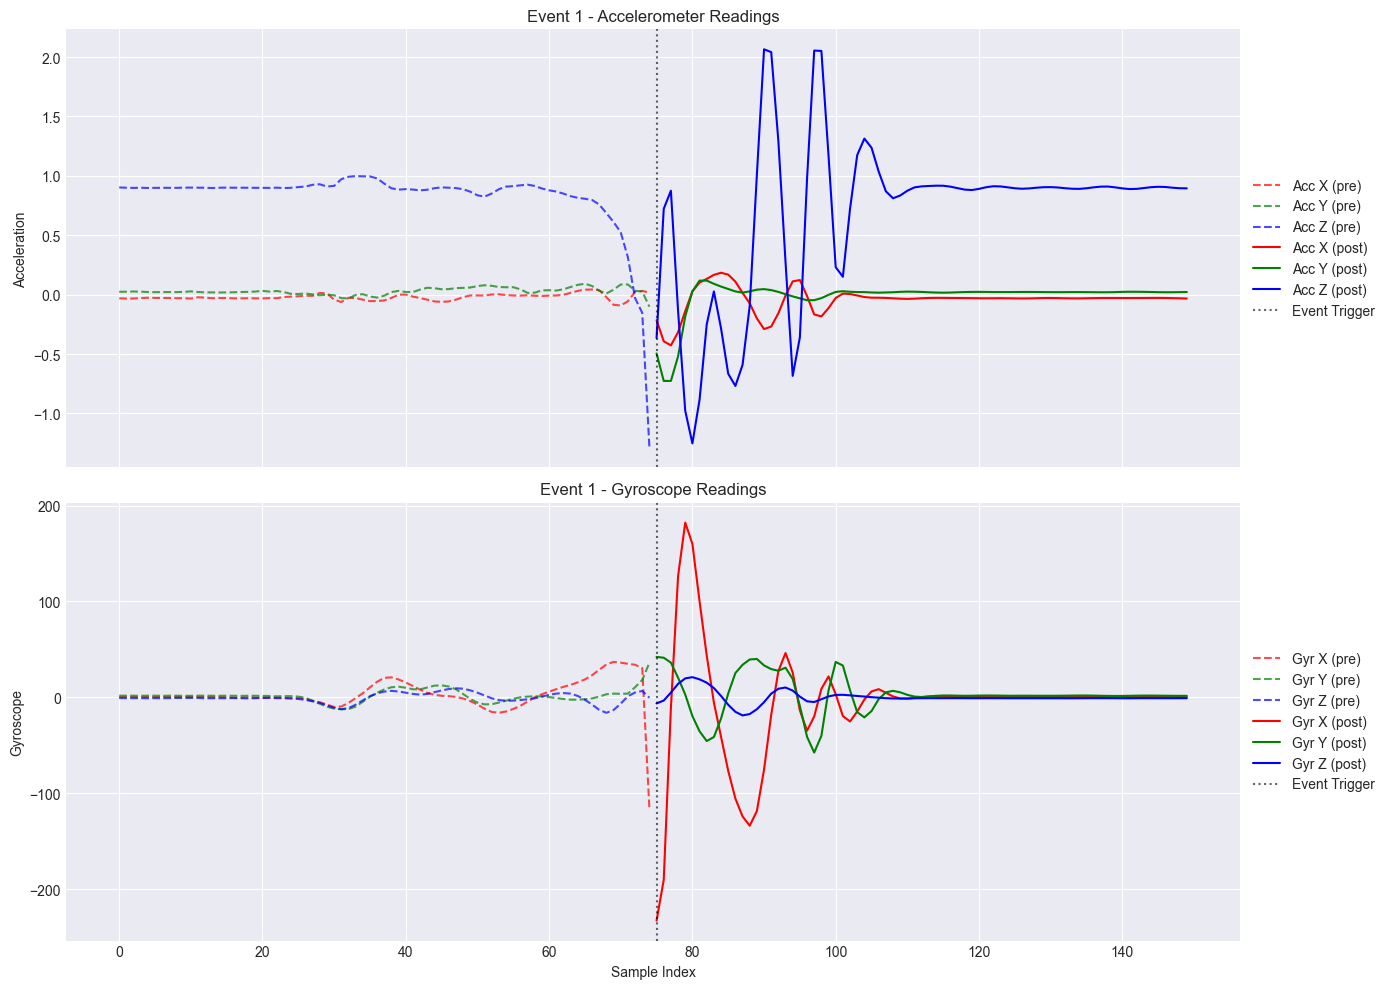

     id  event_id pre_post     acc_x     acc_y     acc_z      gyr_x  \
73  224         2      pre -0.045166  0.017822  0.976074  -5.203125   
74  225         2      pre  0.011230 -0.046387  1.973389 -10.484375   

        gyr_y    gyr_z  sample_idx  
73   8.203125 -0.71875          73  
74  25.390625 -0.56250          74  
     id  event_id pre_post     acc_x     acc_y     acc_z     gyr_x      gyr_y  \
75  226         2     post  0.038818 -0.044922  1.497314  7.718750  13.937500   
76  227         2     post -0.000732 -0.016113  1.028809  8.734375   7.328125   

      gyr_z  sample_idx  
75 -1.43750          75  
76 -1.90625          76  


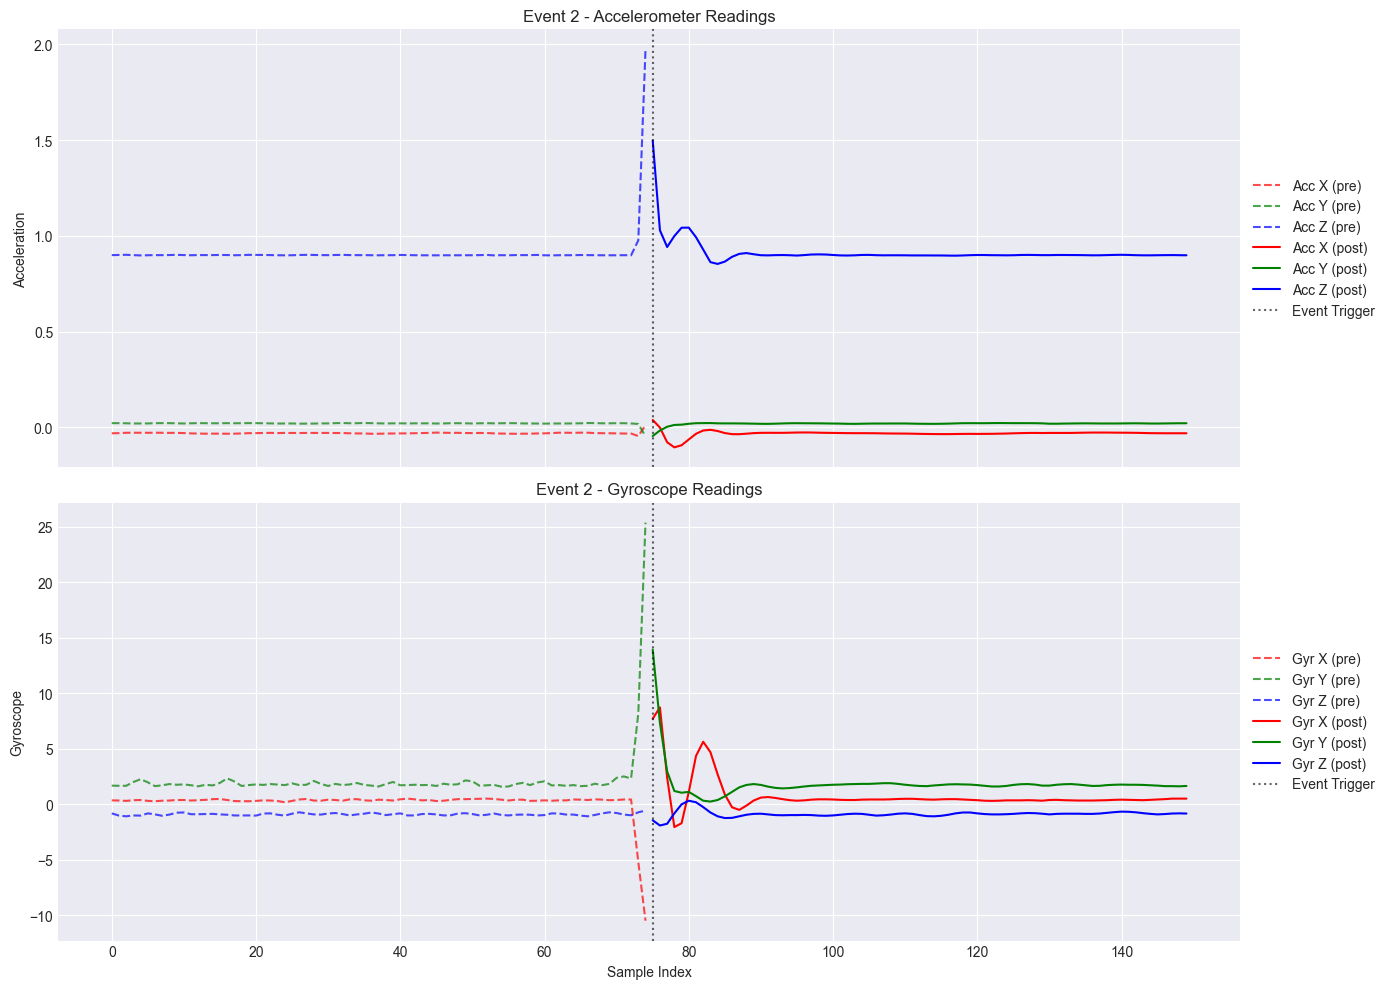

     id  event_id pre_post     acc_x     acc_y     acc_z      gyr_x     gyr_y  \
73  374         3      pre -0.029541  0.020264  0.897949   0.312500  1.796875   
74  375         3      pre -0.117676 -0.027344  1.336670 -19.921875 -4.703125   

       gyr_z  sample_idx  
73 -0.953125          73  
74 -0.671875          74  
     id  event_id pre_post     acc_x     acc_y     acc_z      gyr_x     gyr_y  \
75  376         3     post -0.159668 -0.045166  1.540039  -0.921875 -5.968750   
76  377         3     post -0.142334 -0.021973  1.122314  25.843750 -5.421875   

      gyr_z  sample_idx  
75 -1.03125          75  
76 -1.09375          76  


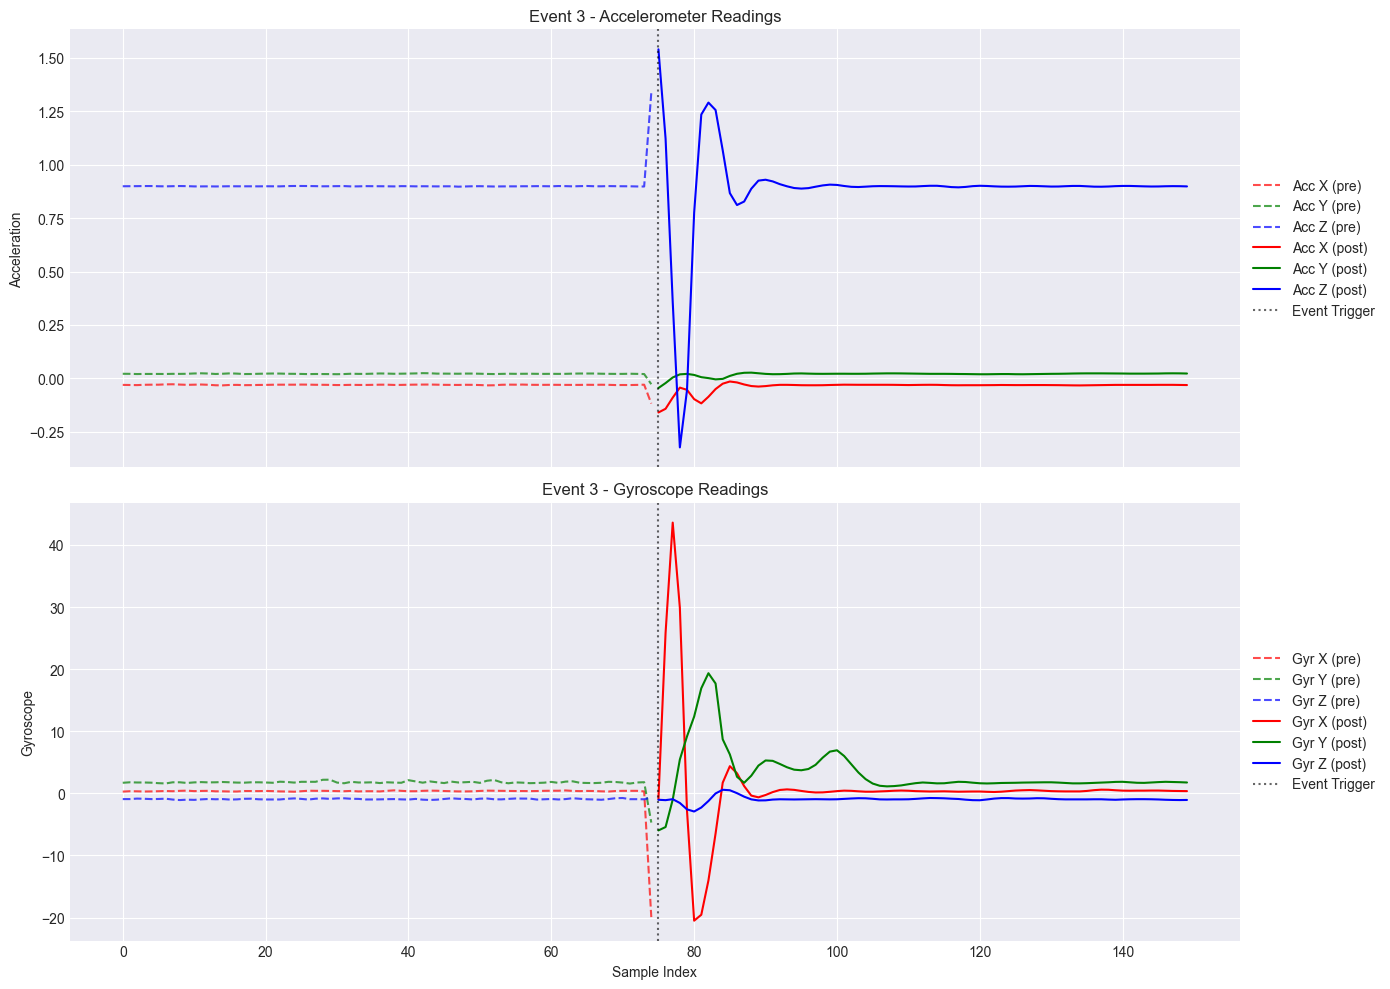

In [11]:
def plot_event(event_id):
    # Fetch data for the specific event, ordered by ID to maintain sequence
    query = f"SELECT * FROM event_data WHERE event_id = {event_id} ORDER BY id"
    event_data = pd.read_sql_query(query, conn)
    
    if event_data.empty:
        print(f"No data found for event ID {event_id}")
        return
    
    # Reset index so we have sequential sample numbers
    event_data = event_data.reset_index(drop=True)
    event_data['sample_idx'] = event_data.index
    
    # Separate pre-event and post-event data
    pre_event = event_data[event_data['pre_post'] == 'pre']
    post_event = event_data[event_data['pre_post'] == 'post']
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    print(pre_event[-2:])
    print(post_event[:2])
    # --- Plot Accelerometer ---
    if not pre_event.empty:
        ax1.plot(pre_event['sample_idx'], pre_event['acc_x'], 'r--', label='Acc X (pre)', alpha=0.7)
        ax1.plot(pre_event['sample_idx'], pre_event['acc_y'], 'g--', label='Acc Y (pre)', alpha=0.7)
        ax1.plot(pre_event['sample_idx'], pre_event['acc_z'], 'b--', label='Acc Z (pre)', alpha=0.7)
        
    if not post_event.empty:
        ax1.plot(post_event['sample_idx'], post_event['acc_x'], 'r-', label='Acc X (post)')
        ax1.plot(post_event['sample_idx'], post_event['acc_y'], 'g-', label='Acc Y (post)')
        ax1.plot(post_event['sample_idx'], post_event['acc_z'], 'b-', label='Acc Z (post)')
    
    ax1.set_title(f"Event {event_id} - Accelerometer Readings")
    ax1.set_ylabel("Acceleration")
    ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    
    # --- Plot Gyroscope ---
    if not pre_event.empty:
        ax2.plot(pre_event['sample_idx'], pre_event['gyr_x'], 'r--', label='Gyr X (pre)', alpha=0.7)
        ax2.plot(pre_event['sample_idx'], pre_event['gyr_y'], 'g--', label='Gyr Y (pre)', alpha=0.7)
        ax2.plot(pre_event['sample_idx'], pre_event['gyr_z'], 'b--', label='Gyr Z (pre)', alpha=0.7)
        
    if not post_event.empty:
        ax2.plot(post_event['sample_idx'], post_event['gyr_x'], 'r-', label='Gyr X (post)')
        ax2.plot(post_event['sample_idx'], post_event['gyr_y'], 'g-', label='Gyr Y (post)')
        ax2.plot(post_event['sample_idx'], post_event['gyr_z'], 'b-', label='Gyr Z (post)')
    
    ax2.set_title(f"Event {event_id} - Gyroscope Readings")
    ax2.set_ylabel("Gyroscope")
    ax2.set_xlabel("Sample Index")
    ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    
    # Add vertical line to indicate transition point if both datasets exist
    if not pre_event.empty and not post_event.empty:
        transition_idx = post_event['sample_idx'].iloc[0]
        ax1.axvline(x=transition_idx, color='k', linestyle=':', alpha=0.6, label='Event Trigger')
        ax2.axvline(x=transition_idx, color='k', linestyle=':', alpha=0.6, label='Event Trigger')
        # The line might overwrite legends if we don't recreate it
        ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    
    plt.tight_layout()
    plt.show()

# Example: Plot the first 3 events
if not events_df.empty:
    for event_id in events_df['id'].head(3):
        plot_event(event_id)
else:
    print("No events to display.")